In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\it's
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\it's
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("../dataset/reviews.csv")

In [4]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [6]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [7]:
df = df[['product_name',
         'category',
         'rating',
         'review_title',
         'review_content']]

In [8]:
df.rename(columns={
    'product_name':'Product',
    'review_title':'Title',
    'review_content':'Review'
}, inplace=True)

In [9]:
df.dropna(inplace=True)

In [10]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [11]:
df.dropna(subset=['rating'], inplace=True)

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)

In [13]:
df[['Review', 'Cleaned_Review']].head()

,Review,Cleaned_Review
0,Looks durable Charging is fine tooNo complains...,looks durable charging fine toono complains ch...
1,I ordered this cable to connect my phone to An...,ordered cable connect phone android auto car c...
2,"Not quite durable and sturdy,https://m.media-a...",quite durable sturdy https media amazon com im...
3,"Good product,long wire,Charges good,Nice,I bou...",good product long wire charges good nice bough...
4,"Bought this instead of original apple, does th...",bought instead original apple work rs fast app...


In [14]:
def rating_sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

In [15]:
df['Sentiment'] = df['rating'].apply(rating_sentiment)

In [16]:
df['Sentiment'].value_counts()

Sentiment
Positive    1110
Negative     350
Neutral        4
Name: count, dtype: int64

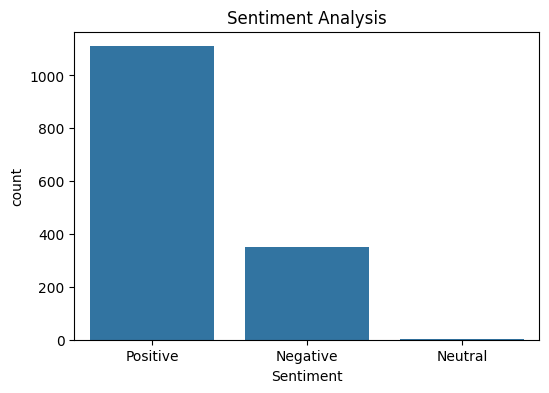

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Analysis")

plt.show()

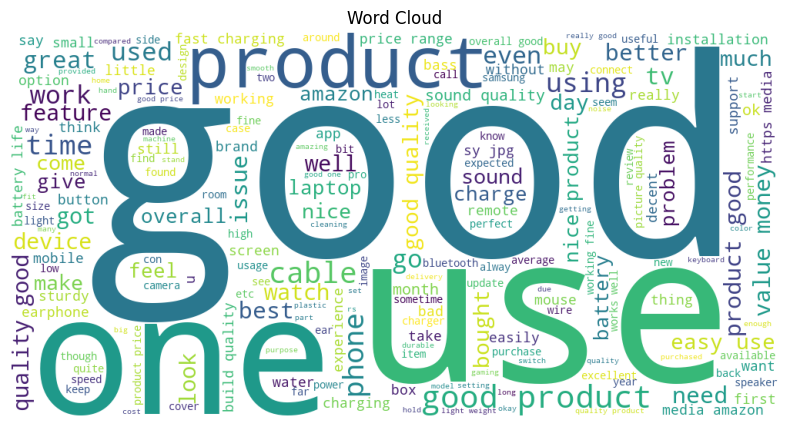

In [18]:
text = " ".join(df['Cleaned_Review'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

In [19]:
from collections import Counter

all_words = text.split()

common_words = Counter(all_words).most_common(20)

common_words

[('good', 6461),
 ('product', 3952),
 ('quality', 2421),
 ('use', 1729),
 ('one', 1455),
 ('price', 1394),
 ('cable', 1380),
 ('like', 1243),
 ('also', 1226),
 ('phone', 1094),
 ('charging', 1015),
 ('using', 1006),
 ('nice', 970),
 ('easy', 946),
 ('battery', 881),
 ('well', 877),
 ('working', 864),
 ('time', 848),
 ('amazon', 782),
 ('buy', 774)]

In [20]:
cv = CountVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words='english'
)

dtm = cv.fit_transform(df['Cleaned_Review'])

In [21]:
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [22]:
for index, topic in enumerate(lda.components_):

    print(f"\nTopic {index+1}")

    print([cv.get_feature_names_out()[i]
           for i in topic.argsort()[-10:]])


Topic 1
['like', 'value', 'working', 'money', 'use', 'price', 'nice', 'cable', 'quality', 'product']

Topic 2
['power', 'screen', 'price', 'time', 'like', 'watch', 'quality', 'camera', 'battery', 'phone']

Topic 3
['price', 'used', 'time', 'like', 'using', 'watch', 'water', 'easy', 'use', 'product']

Topic 4
['like', 'using', 'fast', 'price', 'product', 'sound', 'charging', 'tv', 'quality', 'cable']

Topic 5
['nice', 'sy', 'jpg', 'media', 'https', 'com', 'amazon', 'images', 'quality', 'product']


In [23]:
df.to_csv("final_reviews.csv", index=False)

In [24]:
import os

os.getcwd()

"C:\\Users\\it's Owner\\Downloads\\Customer_Feedback_Analysis\\notebook"

In [25]:
os.listdir()

['.ipynb_checkpoints',
 'Customer_Feedback_Analysisi.ipynb',
 'final_reviews.csv']

In [26]:
df.to_csv("../output/final_reviews.csv", index=False)